# Optuna optimization — typed continuous spaces and trial diagnostics


## Goal
Run a reproducible typed Optuna study over continuous/log-scaled SVC parameters. We inspect convergence, explored parameter space, trial ranking and secondary metrics. SVC probabilities are intentionally **not** enabled; ROC-AUC uses the decision function.


In [1]:
import os
os.environ.setdefault("MPLBACKEND", "Agg")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DEMO_TEST = os.getenv("SABER_DEMO_TEST") == "1"

def balanced_fold_labels(y, n_splits):
    """Demo-only external memberships. Production partition generation belongs to BioSieve."""
    y = np.asarray(y)
    folds = np.empty(len(y), dtype=int)
    for label in np.unique(y):
        idx = np.flatnonzero(y == label)
        folds[idx] = np.arange(len(idx)) % n_splits
    return folds

from sklearn.datasets import make_classification
from saber import tune
from saber.core import SearchSpace, LogFloat, Categorical
from saber.datasets import DatasetBundle, PartitionPlan
from saber.tuning import TuningConfig


In [2]:
n_samples=140 if DEMO_TEST else 320
X,y=make_classification(n_samples=n_samples,n_features=12,n_informative=8,class_sep=1.05,random_state=54)
ids=[f"opt_{i:04d}" for i in range(len(y))]
dataset=DatasetBundle(X=X,y=y,sample_ids=ids,feature_names=[f"f{i}" for i in range(X.shape[1])])
plan=PartitionPlan.from_predefined_folds(sample_ids=ids,fold_assignments=balanced_fold_labels(y,4),dataset_fingerprint=dataset.fingerprint)
space=SearchSpace("svc_optuna",{"C":LogFloat(1e-2,30.0),"gamma":LogFloat(1e-4,1.0),"kernel":Categorical(["rbf"])})


In [3]:
n_trials=8 if DEMO_TEST else 28
config=TuningConfig(optimizer="optuna",metrics=("mcc","roc_auc","balanced_accuracy"),refit_metric="mcc",n_trials=n_trials,random_state=123,n_jobs=1)
opt=tune(dataset=dataset,algorithm="svc",config=config,partition_plan=plan,search_space=space)
history=opt.history_frame(); completed=history[history.status=="complete"].reset_index(drop=True)
score_col=next(c for c in completed.columns if c in {"metric__mcc","metric__mcc__mean"})
completed["best_so_far"]=completed[score_col].cummax()
top=completed.nlargest(min(5,len(completed)),score_col)
print("Best:",opt.best_params,opt.display_scores); top[["param__C","param__gamma",score_col]].head()


[I 2026-09-13 18:20:31,614] A new study created in memory with name: no-name-99eac1e9-3821-43ce-b946-dad5177d7f2a
[I 2026-09-13 18:20:31,659] Trial 0 finished with value: 0.6325448134713629 and parameters: {'C': 2.6406315537410094, 'gamma': 0.0013949458198611203, 'kernel': 'rbf'}. Best is trial 0 with value: 0.6325448134713629.
[I 2026-09-13 18:20:31,706] Trial 1 finished with value: 0.3086025509342061 and parameters: {'C': 0.06148794955909679, 'gamma': 0.01604202084518248, 'kernel': 'rbf'}. Best is trial 0 with value: 0.6325448134713629.
[I 2026-09-13 18:20:31,752] Trial 2 finished with value: 0.6349771646956126 and parameters: {'C': 3.174540316423177, 'gamma': 0.00492522233779106, 'kernel': 'rbf'}. Best is trial 2 with value: 0.6349771646956126.
[I 2026-09-13 18:20:31,794] Trial 3 finished with value: 0.7886380210829226 and parameters: {'C': 25.71793178625207, 'gamma': 0.05486797781181634, 'kernel': 'rbf'}. Best is trial 3 with value: 0.7886380210829226.
[I 2026-09-13 18:20:31,851] T

Best: {'C': 5.370694936952614, 'gamma': 0.14539044054896655, 'kernel': 'rbf'} {'mcc': 0.8451803241789924, 'roc_auc': 0.9697028416197624, 'balanced_accuracy': 0.9218593652282677}


,param__C,param__gamma,metric__mcc
22,5.370695,0.145390,0.845180
16,8.522678,0.216656,0.838980
11,27.417437,0.158511,0.838579
13,8.751007,0.086438,0.838220
24,14.646433,0.191424,0.832619


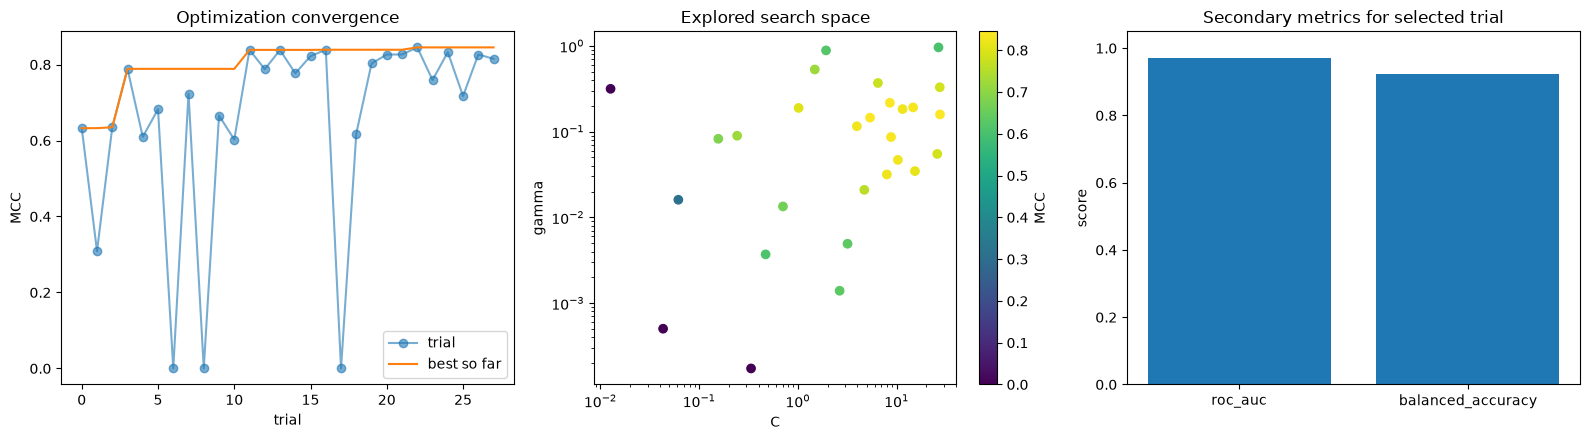

In [4]:
fig,axes=plt.subplots(1,3,figsize=(16,4.5))
axes[0].plot(np.arange(len(completed)),completed[score_col],"o-",alpha=.6,label="trial"); axes[0].plot(completed.best_so_far,label="best so far"); axes[0].set(title="Optimization convergence",xlabel="trial",ylabel="MCC"); axes[0].legend()
sc=axes[1].scatter(completed.param__C,completed.param__gamma,c=completed[score_col]); axes[1].set_xscale("log"); axes[1].set_yscale("log"); axes[1].set(title="Explored search space",xlabel="C",ylabel="gamma"); fig.colorbar(sc,ax=axes[1],label="MCC")
secondary_scores=pd.Series({k:v for k,v in opt.display_scores.items() if k!="mcc"})
axes[2].bar(secondary_scores.index,secondary_scores.values)
axes[2].set(title="Secondary metrics for selected trial",ylabel="score",ylim=(0,1.05))
plt.tight_layout(); FIGURE_COUNT=1


In [5]:
DEMO_CHECKS={
    "requested_trials": len(history)==n_trials,
    "all_complete": (history.status=="complete").all(),
    "finite_best": np.isfinite(opt.best_score),
    "study_available": opt.study is not None,
    "typed_parameters": {"param__C","param__gamma"}.issubset(history.columns),
    "monotonic_best": completed.best_so_far.is_monotonic_increasing,
    "secondary_metrics": len(secondary_scores)>=2,
    "figure_created": FIGURE_COUNT==1,
}
assert all(DEMO_CHECKS.values()), DEMO_CHECKS
DEMO_CHECKS


{'requested_trials': True,
 'all_complete': np.True_,
 'finite_best': np.True_,
 'study_available': True,
 'typed_parameters': True,
 'monotonic_best': True,
 'secondary_metrics': True,
 'figure_created': True}